In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from tqdm import tqdm
import time
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer


nltk.download('stopwords')
stop = stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:


def tensor_product(p, q, r):
    """
    Constructs a d x d x d tensor by multiplying three vectors together.

    Parameters:
    p (numpy.ndarray): First vector of size d.
    q (numpy.ndarray): Second vector of size d.
    r (numpy.ndarray): Third vector of size d.

    Returns:
    numpy.ndarray: A 3D tensor of shape (d, d, d).
    """
    # Ensure inputs are numpy arrays
    p = np.asarray(p)
    q = np.asarray(q)
    r = np.asarray(r)

    # Reshape vectors for broadcasting and compute the outer product
    tensor_3d = p[:, None, None] * q[None, :, None] * r[None, None, :]

    return tensor_3d

def caratheodory(P, w, d):
    n = len(P)

    assert len(P) == len(w), "Length of points and weights must be the same"
    assert np.isclose(np.sum(w), 1), "Weights must sum to 1"
    assert n > d, "Number of points must be greater than dimension d"
    
    if n <= d + 1:
        return P, w
    
    p1 = P[0]
    A = np.array([P[i] - p1 for i in range(1, n)]).T
    v = null_space(A)
    v1 = -np.sum(v)
    v = np.insert(v, 0, v1)
    
    alpha = min([w[i] / v[i] for i in range(n) if v[i] > 0])
    u = np.array([w[i] - alpha * v[i] for i in range(n)])
    
    S = [P[i] for i in range(n) if u[i] > 0]
    u = [u[i] for i in range(n) if u[i] > 0]
    
    if len(S) > d + 1:
        return caratheodory(S, u, d)

    assert np.isclose(np.sum(u), 1), "Final weights must sum to 1"
    weighted_sum_original = np.dot(np.array(w), np.array(P))
    weighted_sum_reduced = np.dot(np.array(u), np.array(S))
    assert np.allclose(weighted_sum_original, weighted_sum_reduced), "Weighted sums must be preserved"
    
    return np.array(S), np.array(u)

def null_space(A, tol=1e-5):
    u, s, vh = np.linalg.svd(A)
    null_mask = (s <= tol)
    null_space = np.compress(null_mask, vh, axis=0)
    return null_space.T[:, 0]


# write the function for k-streaming algorithm based caraheodory algorithm (take d+2 points and keep reducing the points)


def streaming_caratheodory(P, w, d):

    n = len(P)
    selected_points = P[:d+1]
    selected_weights = w[:d+1]
    
    for i in   tqdm(range(d+1, n)):
        selected_points = np.vstack((selected_points, P[i]))
        selected_weights = np.append(selected_weights, w[i])
        s1=sum(selected_weights)
        selected_weights/=s1
        # print(len(selected_points), len(selected_points[0]))
        # Apply Caratheodory's theorem to reduce the set to d+1 points
        selected_points, selected_weights = caratheodory(np.array(selected_points), np.array(selected_weights), d)
        selected_weights*=s1
        # print(len(selected_points))
    # assert len(selected_points) == d+1
    return selected_points, selected_weights/sum(selected_weights)



In [5]:
df=pd.read_csv('research_paper.csv')

df['text'] = df['TITLE'] + ' ' + df['ABSTRACT']
# delete doccuments which are not from Computer scicece, physics or mathamathics
df = df[(df['Computer Science'] == 1) | (df['Physics'] == 1) | (df['Mathematics'] == 1)]
df = df.reset_index(drop=True)

In [6]:
# remove all the stop words form Text column of the df dataframe

df['text'] = df['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))
df['text'].head()


0    Reconstructing Subject-Specific Effect Maps Pr...
1    Rotation Invariance Neural Network Rotation in...
2    Spherical polyharmonics Poisson kernels polyha...
3    A finite element approximation stochastic Maxw...
4    Comparative study Discrete Wavelet Transforms ...
Name: text, dtype: object

In [7]:

# Vectorizing text column to count words across documents
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['text'])

# Sum up the counts of each word across all documents
word_counts = X.toarray().sum(axis=0)

# Get feature names (words) from the vectorizer
words = vectorizer.get_feature_names_out()

# Create a dictionary mapping words to their document count
word_document_count = dict(zip(words, word_counts))

# Sort the dictionary by the word counts in descending order and take the top 100
top_100_words = sorted(word_document_count.items(), key=lambda x: x[1], reverse=True)[:100]

# Display the results
top_30_words=top_100_words[:30]
print(top_30_words)
top_30_words.extend([('also', 1), ('show', 1), ('two', 1)])


[('data', 9369), ('model', 9314), ('based', 8101), ('using', 7344), ('time', 6712), ('results', 6679), ('paper', 6450), ('learning', 6219), ('problem', 5822), ('method', 5747), ('network', 4929), ('models', 4850), ('new', 4731), ('approach', 4709), ('algorithm', 4621), ('networks', 4436), ('systems', 4390), ('study', 4357), ('high', 4118), ('non', 4012), ('analysis', 3960), ('state', 3957), ('different', 3897), ('proposed', 3895), ('large', 3893), ('methods', 3881), ('number', 3851), ('used', 3838), ('order', 3711), ('present', 3580)]


In [8]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
train=df.copy()
# remove stopwords
stop = stopwords.words('english')
top_30_words1 = [word for word, _ in top_30_words]
df['text'] = df['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop) ]))

df['text']=df['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (top_30_words1)]))
# Drop 'filename' and 'newsgroup' columns if needed
# train = df.drop(columns=['filename', 'newsgroup'], errors='ignore')

# Truncate documents to 40 words
train['text'] = train['text'].apply(lambda x: ' '.join(x.split()[:len(x)]))

# Drop rows with less than 40 words
# train = train[train['text'].apply(lambda x: len(x.split()) >= 40)]

# Create a CountVectorizer with the top 1000 words by frequency
vectorizer_top_1000 = CountVectorizer(max_features=100)
bag_of_words_top_1000 = vectorizer_top_1000.fit_transform(train['text'])


# Remove the top 30 words from the vocabulary
for word in top_30_words1:
    if word in vectorizer_top_1000.vocabulary_:
        del vectorizer_top_1000.vocabulary_[word]
        print(f"Removed '{word}' from vocabulary")

stop1=['for', 'in', 'it', 'the', 'this', 'to', 'we', 'our', 'however', 'one', 'many', 'well']
for word in stop1:
    if word in vectorizer_top_1000.vocabulary_:
        del vectorizer_top_1000.vocabulary_[word]
        # print(f"Removed '{word}' from vocabulary")

# Reset vocabulary indices after removing top 30 words
new_vocab = {word: idx for idx, (word, _) in enumerate(sorted(vectorizer_top_1000.vocabulary_.items(), key=lambda x: x[1]))}
# Reset vocabulary indices after removing top 30 words
vectorizer_top_1000.vocabulary_ = new_vocab

# Get the updated word to index mapping from the modified vocabulary
word_to_idx = vectorizer_top_1000.vocabulary_

# Function to convert a document into its word index sequence
def document_to_index_sequence(doc, word_to_idx):
    words = doc.split()
    word_indices = [word_to_idx[word] for word in words if word in word_to_idx]
    return word_indices

# Convert all documents to their index sequences
train['word_indices'] = train['text'].apply(lambda doc: document_to_index_sequence(doc, word_to_idx))

# Define the number of features (this should be dynamic based on new vocab size)
num_features = len(new_vocab)
num_documents = train.shape[0]

# Initialize the matrix with the updated number of features
matrix = np.zeros((num_documents, num_features), dtype=int)
labels = np.zeros((num_documents, 3), dtype=int)
# Populate the matrix with word counts based on index sequences
for i, word_indices in enumerate(train['word_indices']):
    for idx in word_indices:
        matrix[i, idx] += 1
    labels[i, 0] = train['Computer Science'].iloc[i]
    labels[i, 1] = train['Physics'].iloc[i]
    labels[i, 2] = train['Mathematics'].iloc[i]


# Example: Summing the matrix row at index 124
# print(sum(matrix[124]))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Removed 'data' from vocabulary
Removed 'model' from vocabulary
Removed 'based' from vocabulary
Removed 'using' from vocabulary
Removed 'time' from vocabulary
Removed 'results' from vocabulary
Removed 'paper' from vocabulary
Removed 'learning' from vocabulary
Removed 'problem' from vocabulary
Removed 'method' from vocabulary
Removed 'network' from vocabulary
Removed 'models' from vocabulary
Removed 'new' from vocabulary
Removed 'approach' from vocabulary
Removed 'algorithm' from vocabulary
Removed 'networks' from vocabulary
Removed 'systems' from vocabulary
Removed 'study' from vocabulary
Removed 'high' from vocabulary
Removed 'non' from vocabulary
Removed 'analysis' from vocabulary
Removed 'state' from vocabulary
Removed 'different' from vocabulary
Removed 'proposed' from vocabulary
Removed 'large' from vocabulary
Removed 'methods' from vocabulary
Removed 'number' from vocabulary
Removed 'used' from vocabulary
Removed 'order' from vocabulary
Removed 'present' from vocabulary
Removed 'a

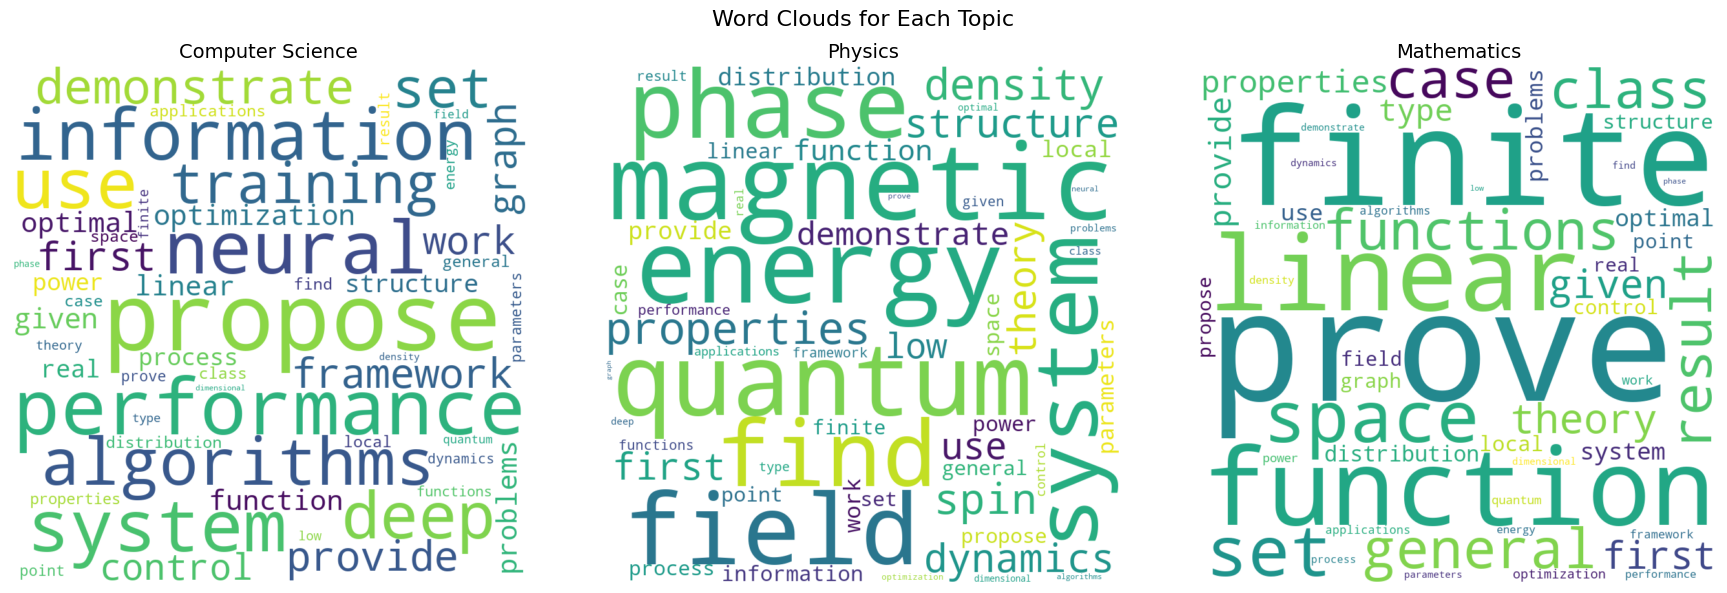

In [9]:
# Create average topic vectors for each topic
topic_vectors = np.zeros((3, num_features), dtype=float)
for i in range(3):
    topic_vectors[i] = np.mean(matrix[labels[:, i] == 1], axis=0)

# Define the topics
topics = ['Computer Science', 'Physics', 'Mathematics']

# Set up a 1x3 grid of subplots (since you only have 3 topics)
fig, axs = plt.subplots(1, 3, figsize=(18, 6))  # Wider layout with 1 row and 3 columns
fig.suptitle('Word Clouds for Each Topic', fontsize=16)

# Get the mapping from index to word (inverse of word_to_idx)
idx_to_word = {v: k for k, v in word_to_idx.items()}

# Iterate over each topic and create the word clouds
for i, ax in enumerate(axs):  # Only iterate over the 3 topics
    # Create a dictionary of words and their corresponding frequencies from topic vector
    word_freq = {idx_to_word[j]: topic_vectors[i][j] for j in range(len(topic_vectors[i])) if topic_vectors[i][j] > 0}

    # Create the word cloud for the topic
    wordcloud = WordCloud(width=800, height=800, background_color='white', stopwords=stop, min_font_size=10).generate_from_frequencies(word_freq)

    # Add the word cloud to the subplot
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(topics[i], fontsize=14)
    ax.axis('off')

# Adjust layout to avoid title overlap and display the plot
plt.tight_layout(rect=[0, 0, 1, 0.97])  # Slight adjustment to title positioning
plt.show()


In [10]:
data=matrix[:1000]

In [11]:
len(matrix[0])


55

In [12]:
from tqdm import tqdm
import numpy as np

def compute_M2_with_progress_memory_efficient(x_samples):
    # Initialize the dimensions
    n = x_samples.shape[0]  # Number of samples (ℓ)
    dim = x_samples.shape[1]  # Dimensionality of each sample

    # Initialize the sum matrix
    M2 = np.zeros((dim, dim))

    # Loop over pairs of samples to compute the pairwise outer product
    for i in tqdm(range(n), desc="Calculating M2"):
        outer_prod = np.outer(x_samples[i], x_samples[i])  # c ⊗ c
        diag_matrix = np.diag(x_samples[i] * x_samples[i])  # diag(c)
        M2 += (outer_prod - diag_matrix)

    # Normalize by ℓ(ℓ - 1)
    M2 /= (n * (n - 1))

    return M2


# Assuming `data` is already defined and preprocessed
# Use `np.float32` for memory efficiency if required
# data = data.astype(np.float32)

# Compute M2 with memory-efficient approach
print("Number of samples (n):", data.shape[0])
M2 = compute_M2_with_progress_memory_efficient(data)
print(len(M2))

Number of samples (n): 1000


Calculating M2:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating M2: 100%|██████████| 1000/1000 [00:00<00:00, 28311.01it/s]

55


In [13]:
k=3
def calculate_whitening_matrix(M2, k):
    _, Sigma, VT= np.linalg.svd(M2)
    sigma=Sigma[:k]
    sigma_inv_root = np.diag(1. / np.sqrt(sigma))
    VT=VT[:k, :] 
    W = VT.T @ sigma_inv_root   
    return W
W=calculate_whitening_matrix(M2, 3)
print(W.T@M2@W)


[[ 1.00000000e+00 -1.29901330e-14 -7.21376249e-17]
 [-1.29654224e-14  1.00000000e+00 -3.22135917e-16]
 [-5.97417302e-19 -3.22514455e-16  1.00000000e+00]]


In [14]:
import numpy as np
from collections import defaultdict
from tqdm import tqdm
from scipy.special import comb
# Assume W and data are predefined
Id = np.eye(data.shape[1])

# Precompute all combinations of tensor products and store in cache
tensor_cache = {}
for d in tqdm(range(data.shape[1]), desc="Precomputing tensor products"):
    for j in range(data.shape[1]):
        ei, ej = Id[d] @ W, Id[j] @ W
        
        # Store flattened tensors in the cache
        tensor_cache[(d, d, d)] = tensor_product(ei, ei, ei).flatten()  # e_i ⊗ e_i ⊗ e_i
        tensor_cache[(d, d, j)] = tensor_product(ei, ei, ej).flatten()  # e_i ⊗ e_i ⊗ e_j
        tensor_cache[(d, j, d)] = tensor_product(ei, ej, ei).flatten()  # e_i ⊗ e_j ⊗ e_i
        tensor_cache[(d, j, j)] = tensor_product(ei, ej, ej).flatten()  # e_i ⊗ e_j ⊗ e_j

# Initialize the final tensor sum
M3_tilda_sum = np.zeros((k,k, k)).flatten()
tensor_list=[]
# Iterate over each row in the dataset and compute M3_tilda
for i in tqdm(range(data.shape[0]), desc="Calculating M3_tilda"):
    whitened_row = data[i] @ W  # Whitening the data row
    c = whitened_row
    c_o = data[i]

    # First term: c ⊗ c ⊗ c
    M3_tilda = tensor_product(c, c, c).flatten()
    
    # Initialize a dictionary to accumulate terms
    m3_dic1 = defaultdict(float)
    
    for d in range(data.shape[1]):
        for j in range(data.shape[1]):
            if d == j:
                M3_tilda += 2 * c_o[d] * tensor_cache[(d, d, d)]
            M3_tilda -= c_o[d] * tensor_cache[(d, d, j)]
            M3_tilda -= c_o[j] * tensor_cache[(d, j, d)]
            M3_tilda -= c_o[d] * tensor_cache[(d, j, j)]
    # measure the size of tehe doccument
    size1=sum(data[i])
    # print(size1)
    if size1>3:
        M3_tilda /= comb(size1, 3) * 6
    tensor_list.append(M3_tilda)

# M3_tilda_sum = np.sum(tensor_list, axis=0)/


Precomputing tensor products:   0%|          | 0/55 [00:00<?, ?it/s]

Calculating M3_tilda: 100%|██████████| 1000/1000 [00:24<00:00, 40.26it/s]


In [15]:
weights=np.ones(len(tensor_list))/len(tensor_list)
print(len(M2))
accurate_coreset, new_weights=streaming_caratheodory( tensor_list,weights, len(tensor_list[0]))


55


100%|██████████| 972/972 [00:00<00:00, 2197.13it/s]


In [16]:
# caculate the weighted mean of the coresets using new_weights
# weighted_coreset=np.zeros(accurate_coreset[0].shape)
cor_start=time.perf_counter()
weighted_coreset=np.zeros(accurate_coreset[0].shape).reshape(k*k*k)
for i in range(accurate_coreset.shape[0]):
    rowi=accurate_coreset[i]*new_weights[i]
    rowi.reshape(k*k*k)
    weighted_coreset+=rowi
# weighted_coreset.shape
cor_end=time.perf_counter()
print(f"Time taken to calculate the weighted mean of the coresets: {cor_end-cor_start} seconds")    
M3_coreset_tilda=weighted_coreset


Time taken to calculate the weighted mean of the coresets: 0.0002660999998624902 seconds


In [17]:
full_start=time.perf_counter()
M3_tilda_sum = np.zeros((k, k, k))
for i in range(len(tensor_list)):
    rowi=tensor_list[i]*weights[i]
    rowi=rowi.reshape(k, k, k)
    M3_tilda_sum+=rowi
full_end=time.perf_counter()
print(f"Time taken to calculate the full M3_tilda: {full_end-full_start} seconds")

# M3_tilda_sum

Time taken to calculate the full M3_tilda: 0.0025467000000389817 seconds


In [18]:

def robust_tensor_power_method(T, L, N): 
    k = T.shape[0]  # Dimension of the tensor
    
    # Step 1: Initialize storage for eigenvalue estimates
    eigenvalue_estimates = np.zeros(L)
    eigenvector_estimates = np.zeros((L, k))
    
    # Step 2: Perform L trials with random initial vectors
    for tau in range(L):
        # Step 2.1: Draw a random initial vector θ(τ)_0 from the unit sphere in R^k
        theta = np.random.randn(k)
        theta /= np.linalg.norm(theta)  # Normalize to make it on the unit sphere
        
        # Step 2.2: Perform N power iterations
        for t in range(N):
            # Compute T(I, θ, θ)
            theta_new = np.tensordot(T, np.outer(theta, theta), axes=([1, 2], [0, 1]))
            # Normalize the resulting vector
            theta_new /= np.linalg.norm(theta_new)
            theta = theta_new
        
        # Store the result of the final power iteration
        eigenvector_estimates[tau] = theta
        # Correct calculation of eigenvalue using einsum
        eigenvalue_estimates[tau] = np.einsum('ijk,i,j,k', T, theta, theta, theta)
    
    # Step 3: Find the best eigenvector/eigenvalue pair
    best_index = np.argmax(eigenvalue_estimates)
    estimated_eigenvector = eigenvector_estimates[best_index]
    estimated_eigenvalue = eigenvalue_estimates[best_index]
    
    # Step 4: Further refine the estimate with additional N iterations
    theta = estimated_eigenvector
    for _ in range(N):
        theta_new = np.tensordot(T, np.outer(theta, theta), axes=([1, 2], [0, 1]))
        theta_new /= np.linalg.norm(theta_new)
        theta = theta_new
    estimated_eigenvector = theta
    # Correct calculation of refined eigenvalue using einsum
    estimated_eigenvalue = np.einsum('ijk,i,j,k', T, theta, theta, theta)
    
    # Step 5: Deflate the tensor
    # Correct calculation of the rank-1 tensor using einsum
    estimated_eigenvector_outer = np.einsum('i,j,k->ijk', estimated_eigenvector, estimated_eigenvector, estimated_eigenvector)
    deflated_tensor = T - estimated_eigenvalue * estimated_eigenvector_outer
    
    return estimated_eigenvector, estimated_eigenvalue, deflated_tensor

L = 10  # Number of trials
N = 10  # Number of power iterations



In [19]:
estimated_eigenvectors1 = []
estimated_eigenvalues1 = []
deflated_tensors1 = []
deflated_tensor1=M3_tilda_sum.reshape(k,k,k)
for _ in range(5):
    estimated_eigenvector1, estimated_eigenvalue1, deflated_tensor1 = robust_tensor_power_method(deflated_tensor1, L, N)
    estimated_eigenvectors1.append(estimated_eigenvector1)
    estimated_eigenvalues1.append(estimated_eigenvalue1)
    deflated_tensors1.append(deflated_tensor1)
print(estimated_eigenvectors1)
print(estimated_eigenvalues1)


[array([ 0.47538872,  0.03545677, -0.87906108]), array([ 0.59891123,  0.78242744, -0.17062426]), array([ 0.47606819, -0.76133713, -0.44014186]), array([ 0.81173899, -0.02675372,  0.58340727]), array([-0.85985759, -0.02862112,  0.50973107])]
[44097.27575455172, 17221.159923993997, 15849.713484901093, 14915.166868794096, 6875.800105495805]


In [20]:
estimated_eigenvectors2 = []
estimated_eigenvalues2 = []
deflated_tensors2 = []
deflated_tensor2 = M3_coreset_tilda.reshape(k,k,k)  

for _ in range(5):
    estimated_eigenvector2, estimated_eigenvalue2, deflated_tensor2 = robust_tensor_power_method(deflated_tensor2, L, N)
    estimated_eigenvectors2.append(estimated_eigenvector2)  # Append the vector to the list
    estimated_eigenvalues2.append(estimated_eigenvalue2)    # Append the value to the list
    deflated_tensors2.append(deflated_tensor2)             # Append the tensor to the list

print(estimated_eigenvectors2)
print(estimated_eigenvalues2)


[array([ 0.4753887 ,  0.03545637, -0.87906111]), array([ 0.59432338,  0.78704683, -0.16533908]), array([ 0.47319838, -0.76309117, -0.440199  ]), array([ 0.81263558, -0.02785557,  0.58210607]), array([-0.85958439, -0.02176227,  0.51053019])]
[44097.27648112213, 17249.736466532322, 15885.14864035086, 14922.271138751643, 6719.584959372945]


In [21]:
W_T = W.T
W_pseudo_inv = np.linalg.pinv(W_T)

def recover_original_distributions(estimated_eigenvectors, estimated_eigenvalues, W_pseudo_inv):
    recovered_centroids = []
    
    for i in range(len(estimated_eigenvectors)):
        estimated_eigenvector = estimated_eigenvectors[i]
        estimated_eigenvalue = estimated_eigenvalues[i]
        
        original_eigenvector =estimated_eigenvalue*W_pseudo_inv @ estimated_eigenvector
        
        recovered_centroids.append(original_eigenvector)

    
    return recovered_centroids

recovered_centroids1 = recover_original_distributions(estimated_eigenvectors1, estimated_eigenvalues1, W_pseudo_inv)
recovered_centroids2 = recover_original_distributions(estimated_eigenvectors2, estimated_eigenvalues2, W_pseudo_inv)

centroids1=recovered_centroids1
centroids2=recovered_centroids2
min_val1 = np.min(centroids1)
if min_val1 < 0:
    centroids1 = centroids1 + (abs(min_val1) + 1e-8)
recovered_centroids1 = centroids1 / centroids1.sum(axis=1)[:, np.newaxis]

# For centroids2
min_val2 = np.min(centroids2)
if min_val2 < 0:
    centroids2 = centroids2 + (abs(min_val2) + 1e-8)
recovered_centroids2 = centroids2 / centroids2.sum(axis=1)[:, np.newaxis]

In [22]:
import pandas as pd

# Get the mapping from index to word (inverse of word_to_idx)
idx_to_word = {v: k for k, v in word_to_idx.items()}

# Number of top words to display
top_n = 30

# Create a dictionary to store the top words for each topic
top_words_dict = {}

# Iterate over each topic vector and find the top words
for i in range(5):  # Assuming we have 3 topic vectors
    # Get the topic vector
    topic_vector = recovered_centroids1[i]
    
    # Get the indices of the top n words in descending order of their weight
    top_word_indices = topic_vector.argsort()[-top_n:][::-1]
    
    # Get the top words and their corresponding weights
    top_words = [(idx_to_word[idx], topic_vector[idx]) for idx in top_word_indices]
    
    # Store the top words and weights in the dictionary
    top_words_dict[f'Topic {i+1}'] = [f"{word}: {weight:.4f}" for word, weight in top_words]

# Convert the dictionary to a DataFrame for better visualization
top_words_df = pd.DataFrame(top_words_dict)
top_words_df

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5
0,low: 0.0338,magnetic: 0.0269,neural: 0.0249,prove: 0.0226,set: 0.0194
1,power: 0.0328,spin: 0.0258,training: 0.0246,finite: 0.0225,propose: 0.0193
2,deep: 0.0326,field: 0.0250,deep: 0.0245,multi: 0.0221,function: 0.0192
3,magnetic: 0.0312,phase: 0.0239,performance: 0.0238,result: 0.0219,given: 0.0191
4,neural: 0.0307,quantum: 0.0230,optimization: 0.0216,dimensional: 0.0218,first: 0.0191
5,training: 0.0305,low: 0.0219,multi: 0.0212,type: 0.0214,information: 0.0189
6,multi: 0.0297,theory: 0.0219,power: 0.0208,class: 0.0211,system: 0.0189
7,spin: 0.0296,dimensional: 0.0217,framework: 0.0203,problems: 0.0211,prove: 0.0189
8,energy: 0.0293,multi: 0.0214,propose: 0.0203,graph: 0.0210,general: 0.0189
9,dynamics: 0.0291,structure: 0.0214,dimensional: 0.0202,functions: 0.0210,use: 0.0189
